# taking all corrected objects dfs and combining them - and analyzing hallucination levels and wrong model extractions
## analyses that should appear here
### bar plots with objects that have all 3 categories to see how many validated objects we have and how many hallucinated objects ther are
### bar plots per participants to see if some hallucinate more than others|

In [70]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_1samp

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

In [71]:
#loading all data frames:
df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditinos_with_digit_span_w_object_hallucinations.csv")
df_perc = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/nlp_analysis/ppt_trials_w_object_validation.csv")
df_immediate = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/05012026_pilot_2_memory/nlp_analysis/ppt_trials_w_object_validation.csv")
df_delay = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/09032026_pilot_2_delayed_memory_digit-span/nlp_analysis/ppt_trials_w_object_validation.csv")

In [ ]:
# df_perc["condition"] = "perception"
# df_immediate["condition"] = "immediate memory"
# df_delay["condition"] = "delayed memory"

In [ ]:
# df = pd.concat([df_perc, df_immediate, df_delay], ignore_index=True)

In [ ]:
# df.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditinos_with_digit_span_w_object_hallucinations.csv", index=False)

In [73]:
# using the clean df 
df = df[df['uid'] != 'qfd4qbm61773068899839']

In [74]:
selected_columns = ['uid', 'condition', 'gt', 'session', 'attempt', 'prompt', 'validated_objects', 'invalid_not_objects', 'invalid_not_in_image',
       'n_extracted', 'n_validated', 'n_invalid_not_object', 'n_invalid_not_in_image', 'diff_in_objects']

In [75]:
df[selected_columns].columns

Index(['uid', 'condition', 'gt', 'session', 'attempt', 'prompt',
       'validated_objects', 'invalid_not_objects', 'invalid_not_in_image',
       'n_extracted', 'n_validated', 'n_invalid_not_object',
       'n_invalid_not_in_image', 'diff_in_objects'],
      dtype='object')

# bar plots with objects, hallucinations and wrong model extractions

In [76]:
# Step 1: Sum the components for each individual attempt (per person)
# This handles cases where one attempt might have multiple rows/prompts
per_session = df.groupby(['uid', 'condition', 'attempt']).agg({
    'n_extracted': 'mean',
    'n_validated': 'mean',
    'n_invalid_not_object': 'mean',
    'n_invalid_not_in_image': 'mean'
}).reset_index()



# Step 2: Average these totals across all users (uids) for each condition/attempt
final_stats = per_session.groupby(['condition', 'attempt']).agg({
    'n_validated': 'mean',
    'n_invalid_not_object': 'mean',
    'n_invalid_not_in_image': 'mean',
    'n_extracted': 'mean'
}).reset_index()

In [77]:
final_stats

,condition,attempt,n_validated,n_invalid_not_object,n_invalid_not_in_image,n_extracted
0,delayed memory,1,3.720000,1.240000,0.280000,5.200000
1,delayed memory,2,4.120000,1.600000,0.400000,6.080000
2,delayed memory,3,4.480000,1.520000,0.480000,6.440000
3,immediate memory,1,4.700000,1.233333,0.500000,6.433333
4,immediate memory,2,5.033333,1.066667,0.466667,6.566667
5,immediate memory,3,4.966667,1.166667,0.266667,6.400000
6,perception,1,5.933333,1.566667,0.100000,7.600000
7,perception,2,6.566667,1.766667,0.100000,8.433333
8,perception,3,7.333333,1.466667,0.233333,9.033333


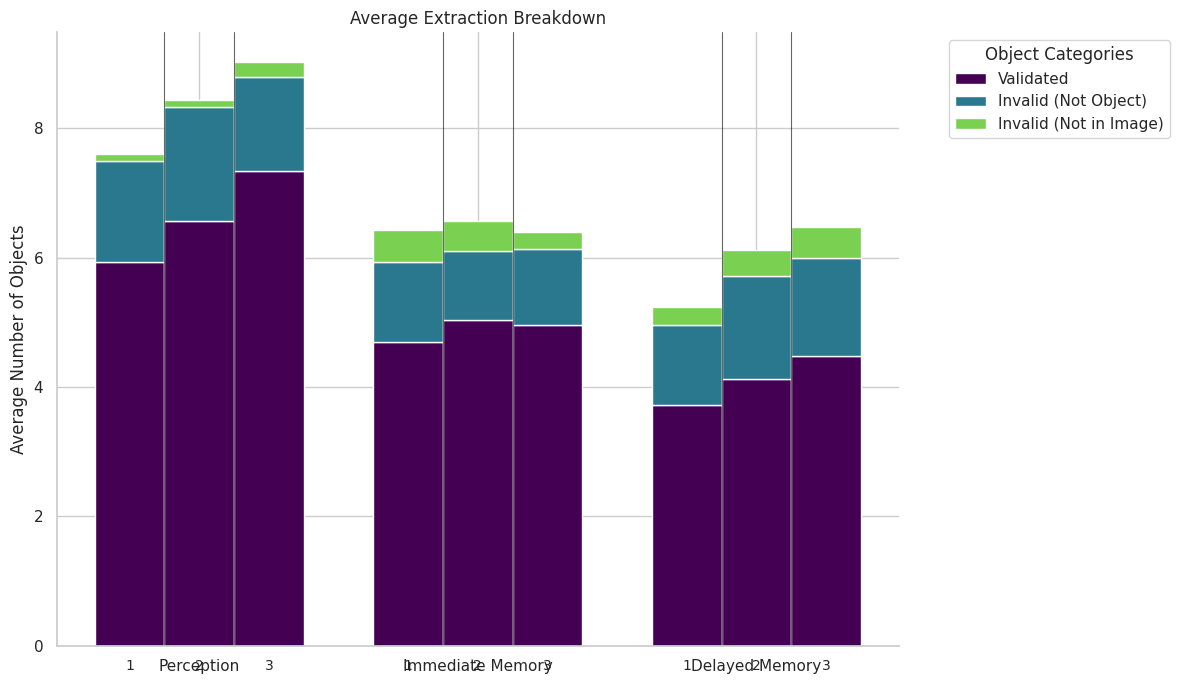

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure these strings match your dataframe EXACTLY
conditions_order = ['perception', 'immediate memory', 'delayed memory']
attempts = [1, 2, 3]

# 2. Setup plotting dimensions
width = 0.25 
x = np.arange(len(conditions_order))
colors = plt.cm.viridis(np.linspace(0, 0.8, 3))
labels = ['Validated', 'Invalid (Not Object)', 'Invalid (Not in Image)']

fig, ax = plt.subplots(figsize=(12, 7))

for i, attempt in enumerate(attempts):
    # Filter for the attempt and reindex to force the specific order
    subset = final_stats[final_stats['attempt'] == attempt].set_index('condition').reindex(conditions_order).fillna(0)
    
    # Calculate horizontal position for attempt 1, 2, and 3
    pos = x + (i - 1) * width
    
    v = subset['n_validated'].values
    ino = subset['n_invalid_not_object'].values
    iii = subset['n_invalid_not_in_image'].values
    
    # Create the stacked bars
    ax.bar(pos, v, width, label=labels[0] if i == 0 else "", color=colors[0])
    ax.bar(pos, ino, width, bottom=v, label=labels[1] if i == 0 else "", color=colors[1])
    ax.bar(pos, iii, width, bottom=v+ino, label=labels[2] if i == 0 else "", color=colors[2])
    
    # Add simple '1', '2', '3' labels below each bar
    for j in range(len(conditions_order)):
        ax.text(pos[j], -0.2, str(attempt), ha='center', va='top', fontsize=10)

# 3. Add lines BETWEEN attempts within each condition group
for j in range(len(conditions_order)):
    # Line between Attempt 1 and 2
    ax.axvline(x=j - width/2, color='black', linewidth=0.8, linestyle='-', alpha=0.6)
    # Line between Attempt 2 and 3
    ax.axvline(x=j + width/2, color='black', linewidth=0.8, linestyle='-', alpha=0.6)

# 4. Final Formatting
ax.set_xticks(x)
ax.set_xticklabels([c.title() for c in conditions_order])
ax.set_ylabel('Average Number of Objects')
ax.set_title('Average Extraction Breakdown')
ax.legend(title="Object Categories", bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Bar plot for learning curve - object count progression - with validated and hallucinated objects. - per condition and attempt

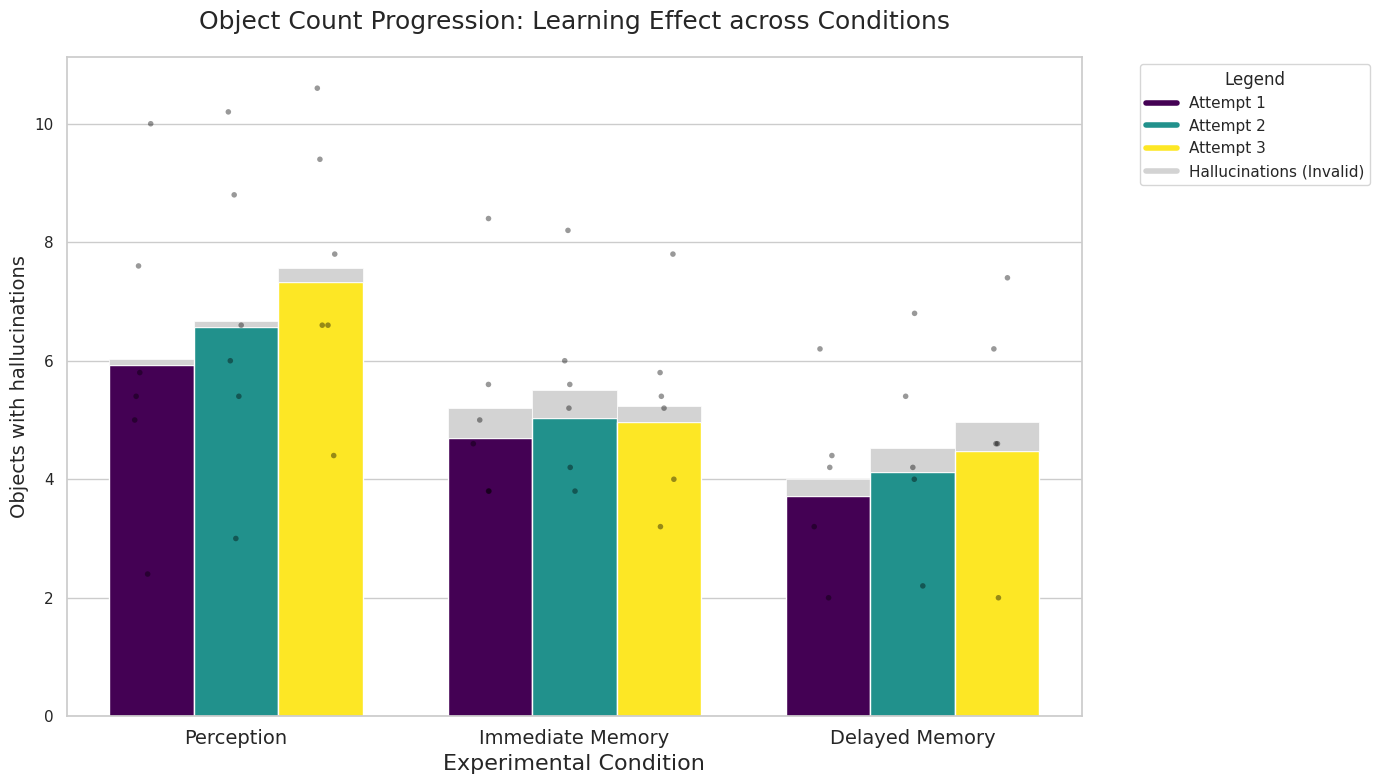

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Aggregation: Get the average per user per condition per attempt
# This ensures the height of the bars matches the individual black dots' distribution
per_user_stats = df.groupby(['uid', 'condition', 'attempt']).agg({
    'n_validated': 'mean',
    'n_invalid_not_in_image': 'mean'
}).reset_index()

# Calculate the mean for the bars
final_stats = per_user_stats.groupby(['condition', 'attempt']).mean(numeric_only=True).reset_index()

# 2. Setup Plotting Parameters
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

conditions = ['perception', 'immediate memory', 'delayed memory']
attempts = [1, 2, 3]
width = 0.25  # width of each attempt bar
x = np.arange(len(conditions))

# Match the palette from your image
colors = {1: '#440154', 2: '#21918c', 3: '#fde725'}
grey_color = '#d3d3d3' # Light grey for the "hallucinations" (invalid_not_in_image)

# 3. Create the Stacked Grouped Bars
for i, attempt in enumerate(attempts):
    # Filter data for specific attempt and align with condition order
    subset = final_stats[final_stats['attempt'] == attempt].set_index('condition').reindex(conditions).fillna(0)
    
    # Horizontal position offset
    pos = x + (i - 1) * width
    
    # Layer 1: Validated (Colored)
    ax.bar(pos, subset['n_validated'], width, color=colors[attempt], label=f'Attempt {attempt}' if i == 0 else "")
    
    # Layer 2: Invalid Not In Image (Grey) - stacked on top
    ax.bar(pos, subset['n_invalid_not_in_image'], width, bottom=subset['n_validated'], 
           color=grey_color, label='Hallucinations' if i == 0 else "", edgecolor='white', linewidth=0.5)

# 4. Add Participant Variability (Dots)
# We use n_validated + n_invalid_not_in_image for the Y position of dots
per_user_stats['total_extracted'] = per_user_stats['n_validated'] + per_user_stats['n_invalid_not_in_image']

sns.stripplot(
    data=per_user_stats,
    x='condition',
    y='total_extracted',
    hue='attempt',
    order=conditions,
    dodge=True,
    palette=['black']*3, # Force all dots black
    alpha=0.4,
    jitter=0.1,
    size=4,
    ax=ax,
    legend=False
)

# 5. Final Styling
ax.set_title('Object Count Progression: Learning Effect across Conditions', fontsize=18, pad=20)
ax.set_ylabel('Objects with hallucinations', fontsize=14)
ax.set_xlabel('Experimental Condition', fontsize=16)

ax.set_xticks(x)
ax.set_xticklabels([c.title() for c in conditions], fontsize=14)

# Custom Legend to clarify colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=colors[1], lw=4, label='Attempt 1'),
    Line2D([0], [0], color=colors[2], lw=4, label='Attempt 2'),
    Line2D([0], [0], color=colors[3], lw=4, label='Attempt 3'),
    Line2D([0], [0], color=grey_color, lw=4, label='Hallucinations (Invalid)')
]
ax.legend(handles=legend_elements, title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### same graph but differnt appearance:

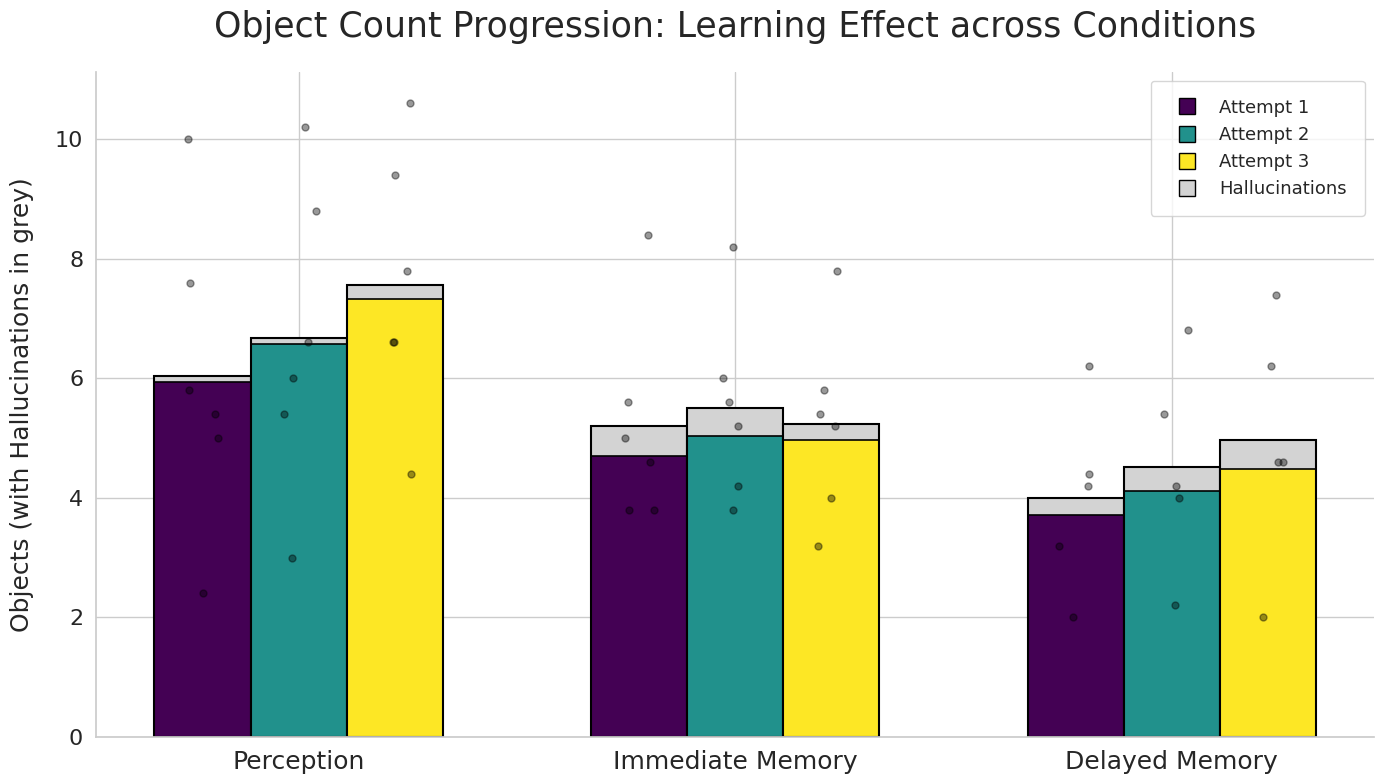

In [80]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Aggregation (Assuming df and per_user_stats are ready)
per_user_stats['total_extracted'] = per_user_stats['n_validated'] + per_user_stats['n_invalid_not_in_image']
final_stats = per_user_stats.groupby(['condition', 'attempt']).mean(numeric_only=True).reset_index()

# 2. Setup
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

conditions = ['perception', 'immediate memory', 'delayed memory']
attempts = [1, 2, 3]
width = 0.22 
x = np.arange(len(conditions))

attempt_colors = {1: '#440154', 2: '#21918c', 3: '#fde725'}
grey_color = '#d3d3d3'

# 3. Plotting Bars
for i, attempt in enumerate(attempts):
    subset = final_stats[final_stats['attempt'] == attempt].set_index('condition').reindex(conditions).fillna(0)
    pos = x + (i - 1) * width
    
    # Layer 1: Validated - REMOVED edgecolor to avoid the middle separation line
    ax.bar(pos, subset['n_validated'], width, 
           color=attempt_colors[attempt], 
           edgecolor='none') 
    
    # Layer 2: Hallucinations (Stacked) - edgecolor='black' but only for the outer boundary
    # We draw this with a zorder to ensure it sits correctly
    ax.bar(pos, subset['n_invalid_not_in_image'], width, 
           bottom=subset['n_validated'], 
           color=grey_color, 
           edgecolor='black', linewidth=1.2)
    
    # To get the black outline around the WHOLE bar without the middle line:
    # We draw an empty bar over the full height
    ax.bar(pos, subset['n_validated'] + subset['n_invalid_not_in_image'], width,
           fill=False, edgecolor='black', linewidth=1.5)

    # 4. LOWERED Attempt Numbers (1, 2, 3)
    # Adjusted 'y' to -0.8 and 'va' to top
    # for j in range(len(conditions)):
    #     ax.text(pos[j], -0.6, str(attempt), ha='center', va='top', fontsize=14, fontweight='bold')

# 5. Add Participant Variability Dots
for i, attempt in enumerate(attempts):
    for j, condition in enumerate(conditions):
        dot_data = per_user_stats[(per_user_stats['condition'] == condition) & 
                                  (per_user_stats['attempt'] == attempt)]
        bar_pos = j + (i - 1) * width
        x_jitter = np.random.uniform(-0.04, 0.04, size=len(dot_data))
        ax.scatter(bar_pos + x_jitter, dot_data['total_extracted'], 
                   color='black', alpha=0.4, s=25, zorder=3)

# 6. Final Polish
ax.set_title('Object Count Progression: Learning Effect across Conditions', fontsize=25, pad=25)
ax.set_ylabel('Objects (with Hallucinations in grey)', fontsize=18, labelpad=15)

ax.set_xticks(x)
ax.set_xticklabels([c.title() for c in conditions], fontsize=18)
plt.yticks(fontsize=16)

# Remove X label title
ax.xaxis.label.set_visible(False)

# 7. Legend (REVERTED to flat style, removed shadow)
legend_elements = [
    Line2D([0], [0], color=attempt_colors[1], lw=0, label='Attempt 1', marker='s', markeredgecolor='black', markersize=12, linestyle='None'),
    Line2D([0], [0], color=attempt_colors[2], lw=0, label='Attempt 2', marker='s', markeredgecolor='black', markersize=12, linestyle='None'),
    Line2D([0], [0], color=attempt_colors[3], lw=0, label='Attempt 3', marker='s', markeredgecolor='black', markersize=12, linestyle='None'),
    Line2D([0], [0], color=grey_color, lw=0, label='Hallucinations', marker='s', markeredgecolor='black', markersize=12, linestyle='None')
]

# Set shadow=False for the previous flat look
ax.legend(handles=legend_elements, loc='upper right', fontsize=13, frameon=True, shadow=False, borderpad=1)

sns.despine()
plt.tight_layout()
plt.show()

## comparison with wilma and chat gpt descriptions